In [1]:
!pip -q install -U tensorflow tensorflow-federated

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.3/887.3 kB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.8/180.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is in

Saving Huntington Disease Dataset.zip to Huntington Disease Dataset.zip
raw dataset shape: (48536, 21)
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Los

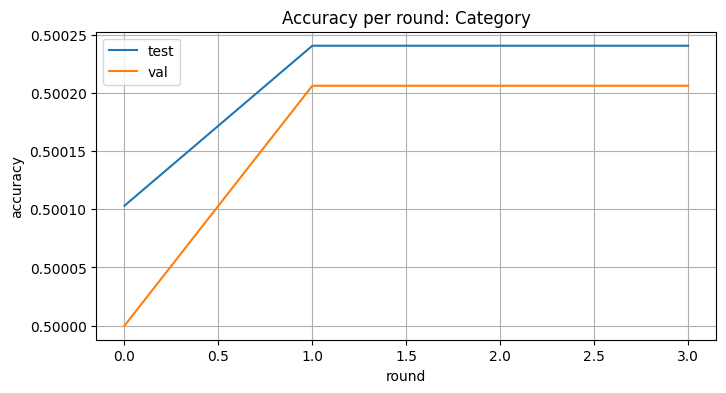

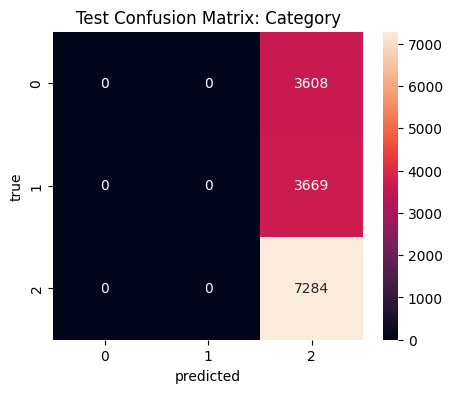

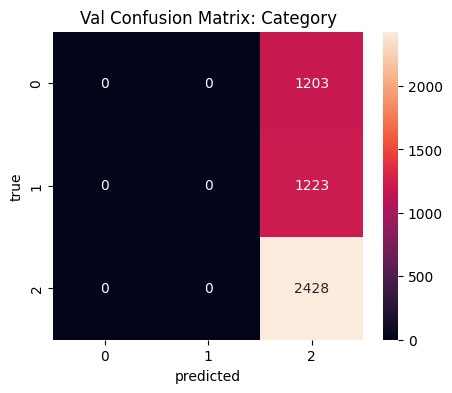


Target: Motor_Symptoms
round 1 test acc: 0.3367 val acc: 0.314
round 2 test acc: 0.3327 val acc: 0.3216
round 3 test acc: 0.3362 val acc: 0.3206
round 4 test acc: 0.334 val acc: 0.3239


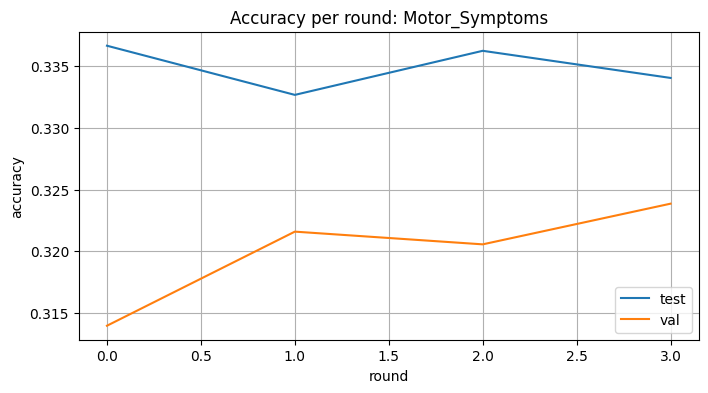

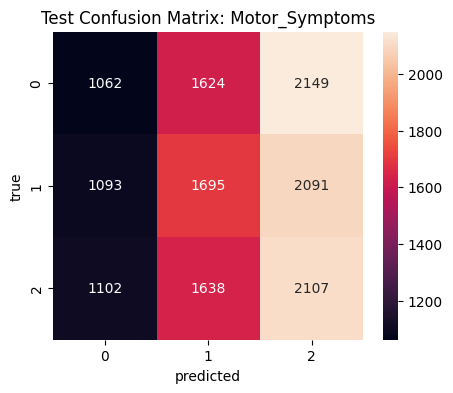

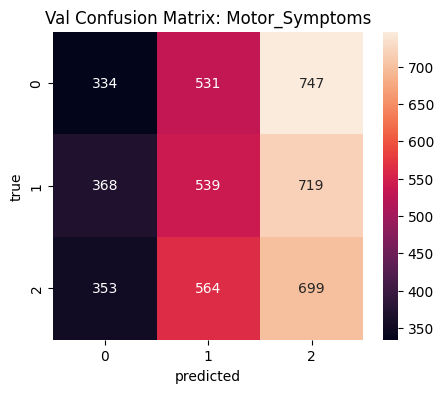


Target: Disease_Stage
round 1 test acc: 0.2535 val acc: 0.2398
round 2 test acc: 0.2503 val acc: 0.2412
round 3 test acc: 0.2516 val acc: 0.239
round 4 test acc: 0.25 val acc: 0.2431


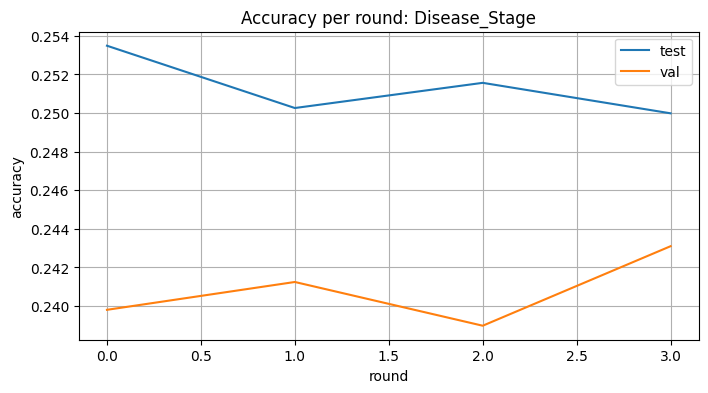

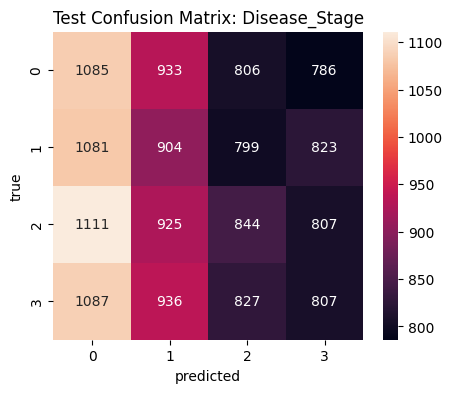

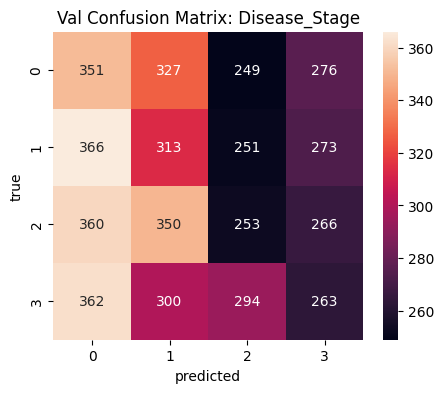


Final Comparison Table
           target  test_accuracy  test_precision  test_recall   test_f1  \
0        Category       0.500240        0.250240     0.500240  0.333600   
1  Motor_Symptoms       0.334043        0.333350     0.334043  0.327953   
2   Disease_Stage       0.249983        0.250316     0.249983  0.249081   

   val_accuracy  
0      0.500206  
1      0.323857  
2      0.243098  

Overall Test Accuracy: 0.3614
Overall Validation Accuracy: 0.3557


In [2]:
# =========================
#SHAPFED FOR HUNTINGTON DATASET
# =========================

import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

tf.random.set_seed(42)
np.random.seed(42)

# =========================
# LOAD ZIP AND CSV
# =========================
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as z:
    z.extractall("/content/")

csv_files = [f for f in os.listdir("/content/") if f.endswith(".csv")]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV found inside the zip file.")
csv_path = os.path.join("/content/", csv_files[0])

df_raw = pd.read_csv(csv_path)
print("raw dataset shape:", df_raw.shape)
print(df_raw.head())

# =========================
# PREPROCESSING
# =========================
df = df_raw.copy()

# remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print("duplicates removed:", before - after)

# drop text heavy or ID columns if they exist
df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors="ignore")

# basic feature engineering
# this only runs if both columns exist
if "Age" in df.columns and "CAG_repeats" in df.columns:
    df["Risk_Score"] = df["Age"] * df["CAG_repeats"]

# identify targets
TARGETS = ["Category", "Motor_Symptoms", "Disease_Stage"]
existing_targets = [t for t in TARGETS if t in df.columns]
if len(existing_targets) == 0:
    raise ValueError("Targets not found. Expected at least one of: Category, Motor_Symptoms, Disease_Stage")

# detect numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()

# keep targets out of feature lists
numeric_cols = [c for c in numeric_cols if c not in TARGETS]
categorical_cols = [c for c in categorical_cols if c not in TARGETS]

# outlier handling using IQR on numeric columns
def cap_outliers_iqr(frame, cols):
    frame = frame.copy()
    for col in cols:
        if col not in frame.columns:
            continue
        x = frame[col]
        if x.isna().all():
            continue
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        frame[col] = x.clip(lower, upper)
    return frame

df = cap_outliers_iqr(df, numeric_cols)

# =========================
# MODEL DEFINITION
# =========================
def build_model(num_features, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(num_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

# =========================
# SHAPFED HELPERS
# =========================
def split_into_clients(X, y, num_clients=3):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    return [(X[s], y[s]) for s in shards]

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def subtract_weights(a, b):
    return [ai - bi for ai, bi in zip(a, b)]

def add_weights(a, b):
    return [ai + bi for ai, bi in zip(a, b)]

def scale_weights(w, s):
    return [x * s for x in w]

def predict_classes(model, X):
    probs = model.predict(X, verbose=0, batch_size=1024)
    return np.argmax(probs, axis=1)

def utility_accuracy(model, X, y):
    preds = predict_classes(model, X)
    return float(accuracy_score(y, preds))

# fast monte carlo shapley weights
def shapley_weights_fast(base_weights, updates, X_eval, y_eval, permutations=6):
    n = len(updates)
    contrib = np.zeros(n, dtype=np.float64)
    temp_model = build_model(X_eval.shape[1], int(np.max(y_eval)) + 1)

    for _ in range(permutations):
        order = np.random.permutation(n)
        w = [bw.copy() for bw in base_weights]
        set_weights(temp_model, w)
        prev_u = utility_accuracy(temp_model, X_eval, y_eval)

        for i in order:
            w = add_weights(w, updates[i])
            set_weights(temp_model, w)
            new_u = utility_accuracy(temp_model, X_eval, y_eval)
            contrib[i] += (new_u - prev_u)
            prev_u = new_u

    contrib = np.maximum(contrib, 0)
    if float(contrib.sum()) == 0.0:
        return np.ones(n, dtype=np.float64) / float(n)
    return contrib / float(contrib.sum())

# =========================
# VISUALS
# =========================
def plot_confusion(y_true, y_pred, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.show()

def plot_accuracy_curve(test_acc, val_acc, title):
    plt.figure(figsize=(8, 4))
    plt.plot(test_acc, label="test")
    plt.plot(val_acc, label="val")
    plt.title(title)
    plt.xlabel("round")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# =========================
# MAIN RUN PER TARGET
# =========================
def run_shapfed_fast_for_target(target):
    print("\n=========================")
    print("Target:", target)
    print("=========================")

    y = df[target].astype("category").cat.codes.to_numpy().astype(np.int32)
    X = df.drop(columns=TARGETS, errors="ignore")

    # preprocessing pipeline
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", __import__("sklearn").preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ], remainder="drop")

    # split 60 30 10
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y if len(np.unique(y)) > 1 else None)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp if len(np.unique(y_temp)) > 1 else None)

    # fit preprocessing on train only
    X_train = preprocessor.fit_transform(X_train).astype(np.float32)
    X_test = preprocessor.transform(X_test).astype(np.float32)
    X_val = preprocessor.transform(X_val).astype(np.float32)

    # optional feature selection
    USE_SELECTK = False
    if USE_SELECTK:
        k = min(50, X_train.shape[1])
        selector = SelectKBest(score_func=f_classif, k=k)
        X_train = selector.fit_transform(X_train, y_train).astype(np.float32)
        X_test = selector.transform(X_test).astype(np.float32)
        X_val = selector.transform(X_val).astype(np.float32)

    # optional PCA
    USE_PCA = False
    if USE_PCA:
        n_comp = min(30, X_train.shape[1])
        pca = PCA(n_components=n_comp, random_state=42)
        X_train = pca.fit_transform(X_train).astype(np.float32)
        X_test = pca.transform(X_test).astype(np.float32)
        X_val = pca.transform(X_val).astype(np.float32)

    # shapfed speed settings
    NUM_CLIENTS = 3
    ROUNDS = 4
    CLIENT_EPOCHS = 1
    BATCH_SIZE = 128
    PERMS = 6

    # small eval subset for shapley utility
    eval_n = min(400, len(X_val))
    idx = np.random.choice(len(X_val), size=eval_n, replace=False)
    X_eval = X_val[idx]
    y_eval = y_val[idx]

    num_features = X_train.shape[1]
    num_classes = int(np.max(y_train)) + 1

    clients = split_into_clients(X_train, y_train, num_clients=NUM_CLIENTS)

    global_model = build_model(num_features, num_classes)
    global_weights = get_weights(global_model)

    test_hist, val_hist = [], []

    for rnd in range(ROUNDS):
        updates = []

        for Xc, yc in clients:
            local = build_model(num_features, num_classes)
            set_weights(local, global_weights)
            local.fit(Xc, yc, epochs=CLIENT_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            updates.append(subtract_weights(get_weights(local), global_weights))

        shap_w = shapley_weights_fast(global_weights, updates, X_eval, y_eval, permutations=PERMS)

        agg = None
        for i, up in enumerate(updates):
            w_up = scale_weights(up, float(shap_w[i]))
            agg = w_up if agg is None else add_weights(agg, w_up)

        global_weights = add_weights(global_weights, agg)
        set_weights(global_model, global_weights)

        test_pred = predict_classes(global_model, X_test)
        val_pred = predict_classes(global_model, X_val)

        test_acc = accuracy_score(y_test, test_pred)
        val_acc = accuracy_score(y_val, val_pred)

        test_hist.append(test_acc)
        val_hist.append(val_acc)

        print("round", rnd + 1, "test acc:", round(float(test_acc), 4), "val acc:", round(float(val_acc), 4))

    plot_accuracy_curve(test_hist, val_hist, "Accuracy per round: " + target)
    plot_confusion(y_test, test_pred, "Test Confusion Matrix: " + target)
    plot_confusion(y_val, val_pred, "Val Confusion Matrix: " + target)

    return {
        "target": target,
        "test_accuracy": float(test_acc),
        "test_precision": float(precision_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_recall": float(recall_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_f1": float(f1_score(y_test, test_pred, average="weighted", zero_division=0)),
        "val_accuracy": float(val_acc)
    }

# =========================
# RUN FOR ALL TARGETS
# =========================
final_results = []
for t in existing_targets:
    final_results.append(run_shapfed_fast_for_target(t))

results_df = pd.DataFrame(final_results)
print("\nFinal Comparison Table")
print(results_df)

print("\nOverall Test Accuracy:", round(float(results_df["test_accuracy"].mean()), 4))
print("Overall Validation Accuracy:", round(float(results_df["val_accuracy"].mean()), 4))
